## Wind Dataset Analysis

This section profiles all GeoJSON files in `data_wind_farm_locations`:
- feature count
- geometry types
- CRS handling (assume EPSG:3301 if missing)
- bounds in WGS84
- key attribute fields

It also creates quick overview plots for visual inspection.


FILE:     tuul_ep_kehtestatud.geojson
STAGE:    established
FEATURES: 2
GEOM:     ['Polygon']
CRS:      EPSG:4326
BOUNDS:   [23.7459 58.3567 24.8328 58.4665]  (minX, minY, maxX, maxY)
COLUMNS:  ['coordinates', 'OBJECTID', 'Plan_nimi', 'KOV', 'Keht_kuup', 'geometry']

FILE:     RMK_MARU_lepingus 3.geojson
STAGE:    contractual
FEATURES: 11
GEOM:     ['MultiPolygon']
CRS:      EPSG:4326
BOUNDS:   [23.7161 57.9872 26.8772 59.422 ]  (minX, minY, maxX, maxY)
COLUMNS:  ['coordinates', 'id', 'Ala_nimi', 'Arendaja', 'geometry']

FILE:     Riigimaade_enampakkumine_voor_alad.geojson
STAGE:    auction_areas
FEATURES: 20
GEOM:     ['MultiPolygon', 'Polygon']
CRS:      EPSG:4326
BOUNDS:   [23.7483 57.9378 27.1962 59.4796]  (minX, minY, maxX, maxY)
COLUMNS:  ['coordinates', 'Ala_nim', 'KOV', 'Pindala_m2', 'Pindala_ha', 'id', 'geometry']

FILE:     Riigimaade_enampakkumine_voor_kataster.geojson
STAGE:    auction_cadastral
FEATURES: 47
GEOM:     ['Polygon', 'MultiPolygon']
CRS:      EPSG:4326
BOUNDS:

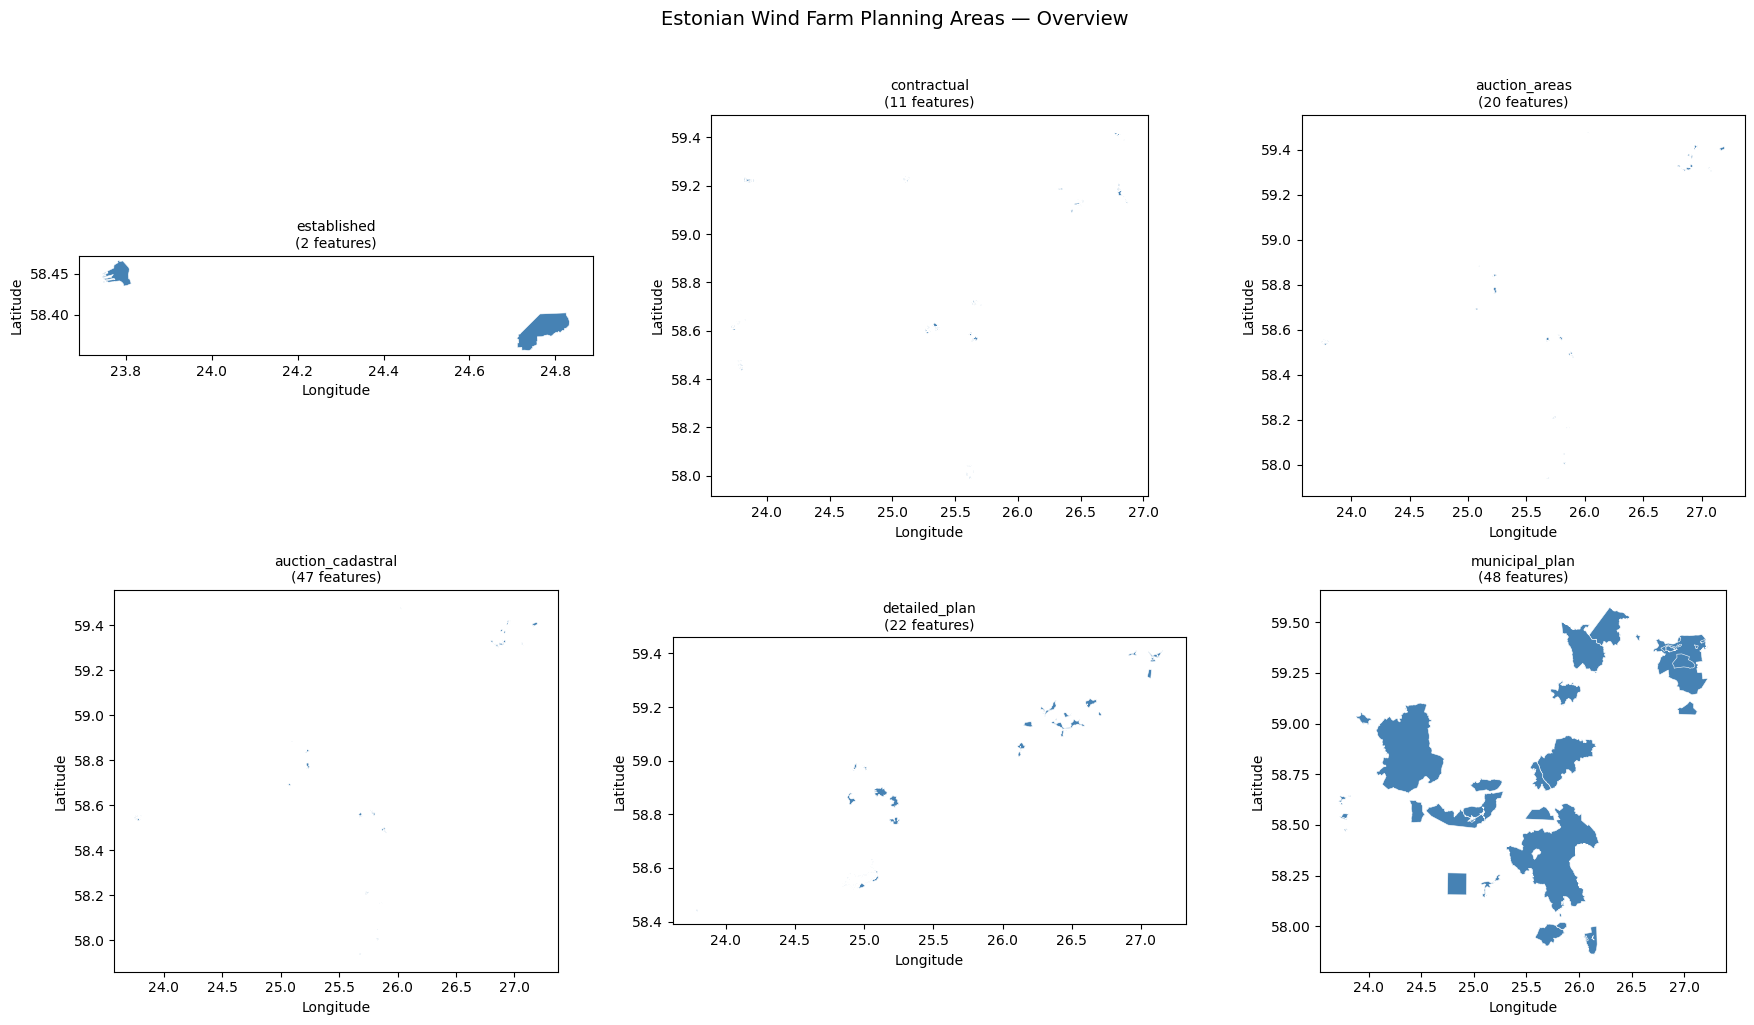

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os

DATA_DIR = "../data_wind_farm_locations"

FILES = {
    "tuul_ep_kehtestatud.geojson":                  "established",
    "RMK_MARU_lepingus 3.geojson":                  "contractual",
    "Riigimaade_enampakkumine_voor_alad.geojson":    "auction_areas",
    "Riigimaade_enampakkumine_voor_kataster.geojson":"auction_cadastral",
    "tuulealad_DP.geojson":                         "detailed_plan",
    "tuuleenergeetika_KOV_EP_alad.geojson":         "municipal_plan",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (fname, stage) in zip(axes, FILES.items()):
    path = os.path.join(DATA_DIR, fname)
    gdf = gpd.read_file(path)

    # Ensure WGS84
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=4326)
    elif gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(epsg=4326)

    print(f"\n{'='*60}")
    print(f"FILE:     {fname}")
    print(f"STAGE:    {stage}")
    print(f"FEATURES: {len(gdf)}")
    print(f"GEOM:     {gdf.geom_type.unique().tolist()}")
    print(f"CRS:      {gdf.crs}")
    print(f"BOUNDS:   {gdf.total_bounds.round(4)}  (minX, minY, maxX, maxY)")
    print(f"COLUMNS:  {gdf.columns.tolist()}")

    gdf.plot(ax=ax, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.set_title(f"{stage}\n({len(gdf)} features)", fontsize=10)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Estonian Wind Farm Planning Areas — Overview", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Step 2: Extract Centroids — Consolidated Wind Farm Locations

For each polygon/multipolygon in every file, compute the WGS84 centroid. This gives one representative coordinate per wind farm area to use as an API query point.

Priority order for weather data collection:
1. **established** — legally enacted plans (Pärnu/Põlendmaa 86 MW, Lääneranna area 2 137 MW)
2. **contractual** — RMK/MARU state forest agreements
3. Other stages for full coverage


In [13]:
import pandas as pd

# Name field to use per file (in priority order)
NAME_FIELDS = {
    "tuul_ep_kehtestatud.geojson":                  ("Plan_nimi",  "KOV"),
    "RMK_MARU_lepingus 3.geojson":                  ("Ala_nimi",   "Arendaja"),
    "Riigimaade_enampakkumine_voor_alad.geojson":    ("Ala_nim",    "KOV"),
    "Riigimaade_enampakkumine_voor_kataster.geojson":("Ala_nim",    "KOV"),
    "tuulealad_DP.geojson":                         ("DP_nimi",    None),
    "tuuleenergeetika_KOV_EP_alad.geojson":         ("Projekti_nimi", "Kohalik_omavalitsus"),
}

rows = []

for fname, stage in FILES.items():
    name_col, muni_col = NAME_FIELDS[fname]
    path = os.path.join(DATA_DIR, fname)
    gdf = gpd.read_file(path)

    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=4326)
    elif gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(epsg=4326)

    for _, row in gdf.iterrows():
        centroid = row.geometry.centroid
        rows.append({
            "source_file":    fname,
            "planning_stage": stage,
            "area_name":      row.get(name_col, ""),
            "municipality":   row.get(muni_col, "") if muni_col else "",
            "centroid_lat":   round(centroid.y, 6),
            "centroid_lon":   round(centroid.x, 6),
        })

locations = pd.DataFrame(rows)

print(f"Total locations: {len(locations)}")
print(f"\nBy planning stage:")
print(locations.groupby("planning_stage").size().to_string())
print(f"\nSample (established plans — highest priority):")
print(locations[locations.planning_stage == "established"][
    ["area_name", "municipality", "centroid_lat", "centroid_lon"]
].to_string(index=False))
# print all locations
print(f"\nAll locations:")
print(locations[["planning_stage", "area_name", "municipality", "centroid_lat", "centroid_lon"]].to_string(index=False))



Total locations: 150

By planning stage:
planning_stage
auction_areas        20
auction_cadastral    47
contractual          11
detailed_plan        22
established           2
municipal_plan       48

Sample (established plans — highest priority):
                                                           area_name    municipality  centroid_lat  centroid_lon
Pärnu linna tuuleenergeetika eriplaneeringu kehtestamine (Põlendmaa)      Pärnu linn     58.382739     24.769711
Lääneranna valla tuuleparkide eriplaneeringu kehtestamine ala 2 osas Lääneranna vald     58.450208     23.784690

All locations:
   planning_stage                                                                                      area_name      municipality  centroid_lat  centroid_lon
      established                           Pärnu linna tuuleenergeetika eriplaneeringu kehtestamine (Põlendmaa)        Pärnu linn     58.382739     24.769711
      established                           Lääneranna valla tuuleparkide eripl

## Step 3: Query OpenWeather Historical API — January 2026

Using the `history.openweathermap.org` endpoint (available on the paid subscription).

The API returns max 168 hours per call, so January 2026 (744 hours) requires 5 calls per location.

We query **all locations** but save the data as we go — if the notebook is interrupted, we can resume. Already-fetched locations are skipped.


In [5]:
import requests
import time
import datetime

API_KEY = "822ed994e581c3d5ec9ce7d445f486e3"
HIST_URL = "http://history.openweathermap.org/data/2.5/history/city"

# January 2026 in UTC unix timestamps
JAN_START = int(datetime.datetime(2026, 1, 1, 0, 0, tzinfo=datetime.timezone.utc).timestamp())
JAN_END   = int(datetime.datetime(2026, 1, 31, 23, 0, tzinfo=datetime.timezone.utc).timestamp())
CHUNK_HOURS = 168  # max per API call
CHUNK_SEC   = CHUNK_HOURS * 3600


def fetch_history_chunk(lat, lon, start_ts, end_ts):
    """Fetch hourly weather history for a coordinate range. Returns list of record dicts."""
    params = {
        "lat":   lat,
        "lon":   lon,
        "type":  "hour",
        "start": start_ts,
        "end":   end_ts,
        "appid": API_KEY,
        "units": "metric",
    }
    resp = requests.get(HIST_URL, params=params, timeout=30)
    if resp.status_code != 200:
        print(f"  ERROR {resp.status_code}: {resp.text[:200]}")
        return []
    data = resp.json()
    return data.get("list", [])


def parse_records(raw_list, area_name, lat, lon):
    """Flatten raw API records into a list of row dicts."""
    parsed = []
    for rec in raw_list:
        wind = rec.get("wind", {})
        main = rec.get("main", {})
        weather = rec.get("weather", [{}])
        parsed.append({
            "timestamp":       datetime.datetime.utcfromtimestamp(rec["dt"]).strftime("%Y-%m-%d %H:%M"),
            "area_name":       area_name,
            "lat":             lat,
            "lon":             lon,
            "wind_speed_ms":   wind.get("speed"),
            "wind_dir_deg":    wind.get("deg"),
            "wind_gust_ms":    wind.get("gust"),
            "temp_c":          main.get("temp"),
            "pressure_hpa":    main.get("pressure"),
            "weather_desc":    weather[0].get("description", ""),
        })
    return parsed


# Test with the first established-plan location before running everything
test_loc = locations[locations.planning_stage == "established"].iloc[0]
print(f"Testing API with: {test_loc['area_name']}")
print(f"  Coords: {test_loc['centroid_lat']}, {test_loc['centroid_lon']}")

test_records = fetch_history_chunk(
    test_loc["centroid_lat"], test_loc["centroid_lon"],
    JAN_START, JAN_START + CHUNK_SEC
)
print(f"  Records returned: {len(test_records)}")
if test_records:
    r = test_records[0]
    print(f"  First record keys: {list(r.keys())}")
    print(f"  Wind speed sample: {r.get('wind', {}).get('speed')} m/s")
    print(f"  Temp sample: {r.get('main', {}).get('temp')} °C")


Testing API with: Pärnu linna tuuleenergeetika eriplaneeringu kehtestamine (Põlendmaa)
  Coords: 58.382739, 24.769711
  Records returned: 162
  First record keys: ['dt', 'main', 'wind', 'clouds', 'weather']
  Wind speed sample: 0 m/s
  Temp sample: -15.01 °C


In [6]:
import os

WEATHER_DIR = "../data_wind_farm_locations/weather_data"
os.makedirs(WEATHER_DIR, exist_ok=True)

# Deduplicate by (lat, lon) — many files may have overlapping areas
locations_unique = (
    locations
    .drop_duplicates(subset=["centroid_lat", "centroid_lon"])
    .reset_index(drop=True)
)
print(f"Unique coordinate points to fetch: {len(locations_unique)}")
print(f"(down from {len(locations)} total features due to deduplication)")

all_rows = []
errors = []

for idx, loc in locations_unique.iterrows():
    area_name = str(loc["area_name"]).strip() or f"area_{idx}"
    lat = loc["centroid_lat"]
    lon = loc["centroid_lon"]
    stage = loc["planning_stage"]

    # Safe filename from area name
    safe_name = area_name[:60].replace("/", "-").replace(" ", "_").replace("(", "").replace(")", "")
    out_path = os.path.join(WEATHER_DIR, f"{safe_name}.csv")

    if os.path.exists(out_path):
        print(f"  [{idx+1}/{len(locations_unique)}] SKIP (cached): {area_name}")
        cached = pd.read_csv(out_path)
        all_rows.append(cached)
        continue

    print(f"  [{idx+1}/{len(locations_unique)}] Fetching: {area_name} ({stage})")

    loc_rows = []
    chunk_start = JAN_START
    while chunk_start < JAN_END:
        chunk_end = min(chunk_start + CHUNK_SEC, JAN_END)
        raw = fetch_history_chunk(lat, lon, chunk_start, chunk_end)
        loc_rows.extend(parse_records(raw, area_name, lat, lon))
        chunk_start += CHUNK_SEC
        time.sleep(0.2)  # be polite to the API

    if loc_rows:
        loc_df = pd.DataFrame(loc_rows)
        loc_df.to_csv(out_path, index=False)
        all_rows.append(loc_df)
        print(f"    → {len(loc_rows)} records saved to {out_path}")
    else:
        errors.append(area_name)
        print(f"    → No data returned!")

if errors:
    print(f"\nLocations with no data: {errors}")

print("\nDone fetching all locations.")


Unique coordinate points to fetch: 143
(down from 150 total features due to deduplication)
  [1/143] SKIP (cached): Pärnu linna tuuleenergeetika eriplaneeringu kehtestamine (Põlendmaa)
  [2/143] SKIP (cached): Lääneranna valla tuuleparkide eriplaneeringu kehtestamine ala 2 osas
  [3/143] SKIP (cached): Põhja-Sakala
  [4/143] SKIP (cached): Lääneranna 1
  [5/143] SKIP (cached): Türi-Järva
  [6/143] SKIP (cached): Vinni-Alutaguse
  [7/143] SKIP (cached): Lääne-Harju
  [8/143] SKIP (cached): Väike-Maarja-Vinni
  [9/143] SKIP (cached): Kose
  [10/143] SKIP (cached): Lüganuse-Viru-Nigula
  [11/143] SKIP (cached): Lääneranna 3
  [12/143] SKIP (cached): Mulgi-Tõrva
  [13/143] SKIP (cached): Türi-Põhjala-Sakala
  [14/143] SKIP (cached): Viljandi (ala 3)
  [15/143] SKIP (cached): Tõrva 2b
  [16/143] SKIP (cached): Viljandi (ala 1)
  [17/143] SKIP (cached): Türi 1
  [18/143] SKIP (cached): Lüganuse (ala 10)
  [19/143] SKIP (cached): Lüganuse (ala 7/62)
  [20/143] SKIP (cached): Lüganuse (ala 2a)

## Step 5: Explore Wind Speed Data — January 2026

Combine all fetched CSVs and analyse:
- Data completeness (missing values, gaps)
- Wind speed distributions per location
- Time series of wind speeds across January (the crisis month)
- Spatial correlation between locations


In [7]:
import glob

# --- Load all CSVs (or reuse all_rows from previous cell) ---
csv_files = glob.glob(os.path.join(WEATHER_DIR, "*.csv"))
if csv_files:
    weather_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
else:
    weather_df = pd.concat(all_rows, ignore_index=True)

weather_df["timestamp"] = pd.to_datetime(weather_df["timestamp"])
weather_df = weather_df.sort_values(["area_name", "timestamp"]).reset_index(drop=True)

print(f"Total records: {len(weather_df)}")
print(f"Unique locations: {weather_df['area_name'].nunique()}")
print(f"Date range: {weather_df['timestamp'].min()}  →  {weather_df['timestamp'].max()}")
print(f"\nMissing values:")
print(weather_df[["wind_speed_ms", "wind_dir_deg", "wind_gust_ms", "temp_c", "pressure_hpa"]].isna().sum())

print(f"\nWind speed summary (m/s):")
print(weather_df.groupby("area_name")["wind_speed_ms"]
      .agg(["mean", "median", "max", "min"])
      .round(2)
      .sort_values("mean", ascending=False)
      .to_string())


Total records: 68019
Unique locations: 91
Date range: 2026-01-01 00:00:00  →  2026-01-31 23:00:00

Missing values:
wind_speed_ms       0
wind_dir_deg        0
wind_gust_ms     1490
temp_c              0
pressure_hpa        0
dtype: int64

Wind speed summary (m/s):
                                                                                                mean  median    max   min
area_name                                                                                                                
Lüganuse (ala 2a)                                                                               4.43    4.08  12.92  0.50
Evecon OÜ ja Enery Estonia OÜ tuuleparkide  KOV EP (ala 2a)                                     4.43    4.08  12.92  0.50
Lüganuse-Viru-Nigula                                                                            4.43    4.08  12.92  0.50
Varja ala 3                                                                                     4.20    3.76  12.30  0.40
Lüg

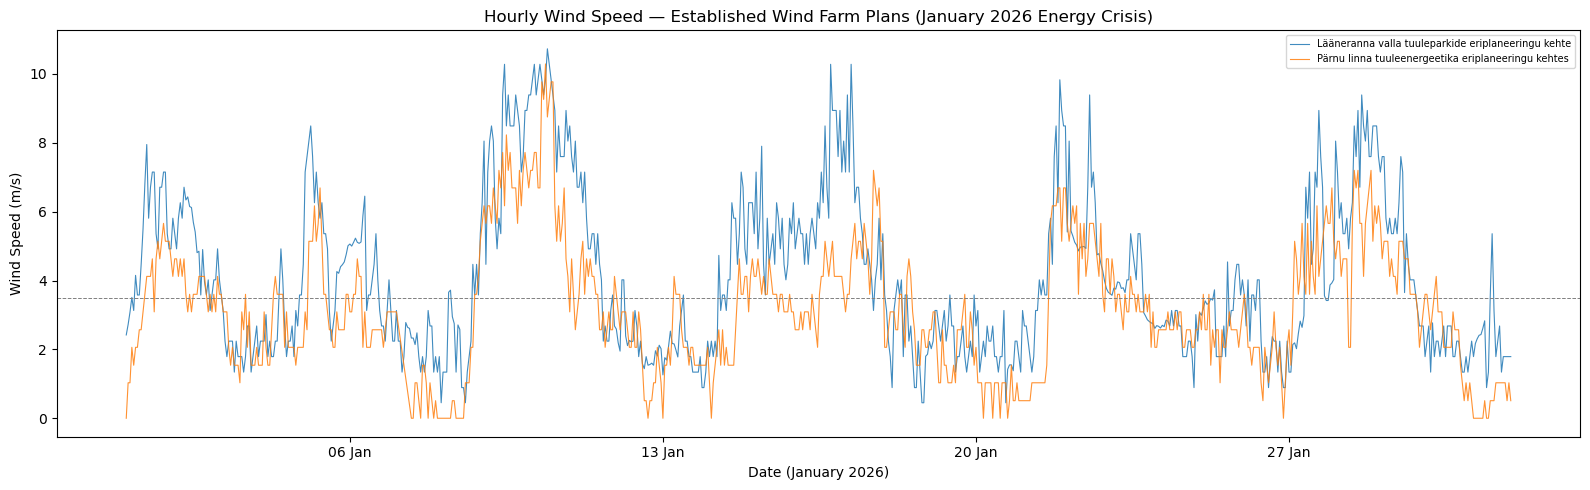

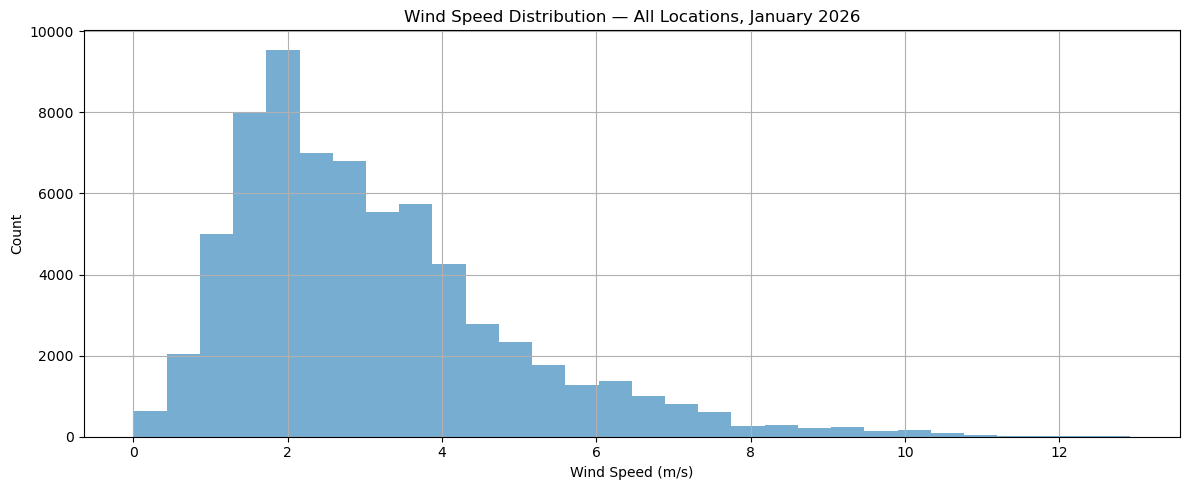

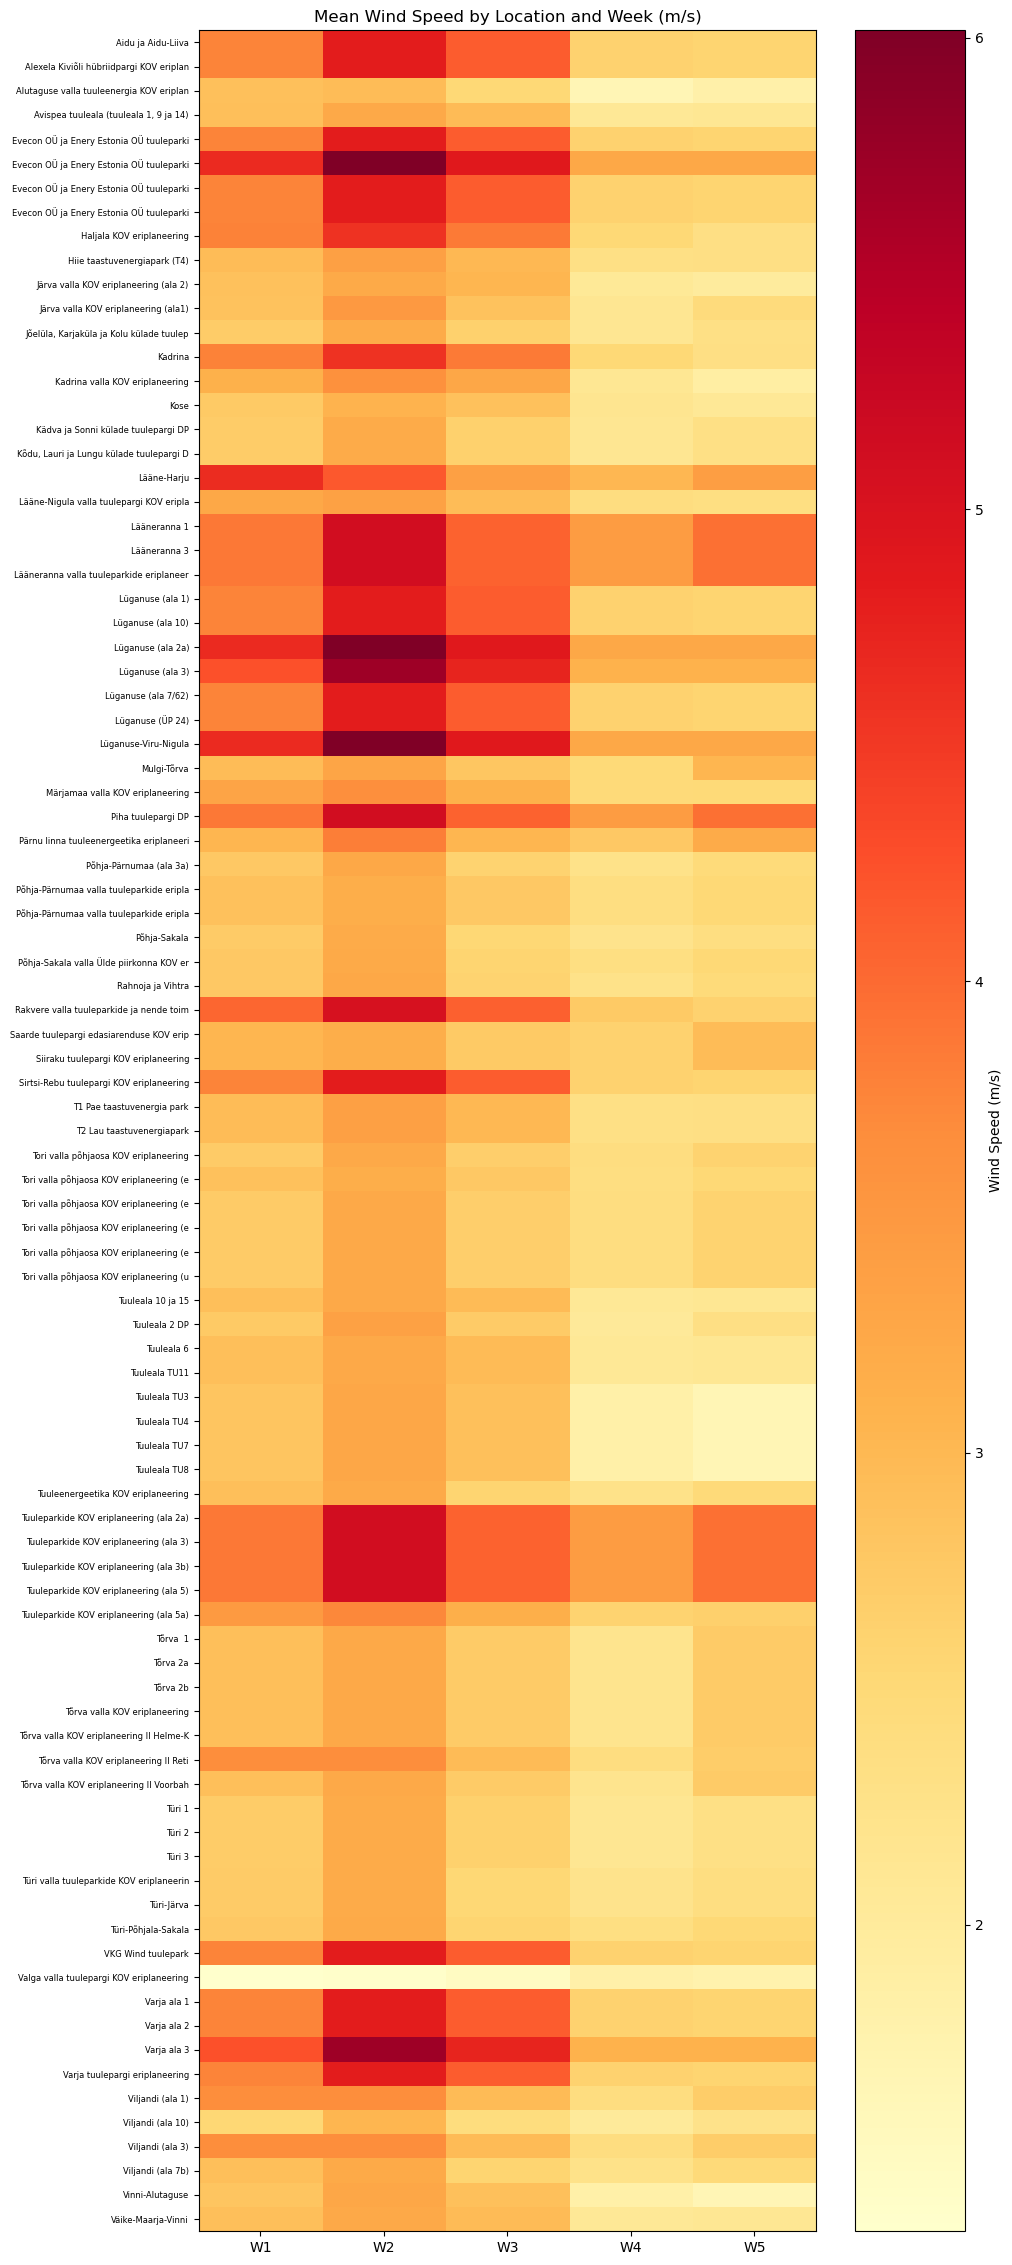

In [8]:
import matplotlib.dates as mdates

# --- Plot 1: Time series of wind speeds — established plan locations ---
established_names = locations[locations.planning_stage == "established"]["area_name"].tolist()
df_est = weather_df[weather_df["area_name"].isin(established_names)]

fig, ax = plt.subplots(figsize=(16, 5))
for name, grp in df_est.groupby("area_name"):
    ax.plot(grp["timestamp"], grp["wind_speed_ms"], label=name[:50], linewidth=0.8, alpha=0.85)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.set_xlabel("Date (January 2026)")
ax.set_ylabel("Wind Speed (m/s)")
ax.set_title("Hourly Wind Speed — Established Wind Farm Plans (January 2026 Energy Crisis)")
ax.legend(fontsize=7, loc="upper right")
ax.axhline(y=3.5, color="gray", linestyle="--", linewidth=0.7, label="Cut-in speed ~3.5 m/s")
plt.tight_layout()
plt.show()

# --- Plot 2: Wind speed distribution (all locations) ---
fig, ax = plt.subplots(figsize=(12, 5))
weather_df.groupby("area_name")["wind_speed_ms"].apply(
    lambda x: x.dropna()
).reset_index(level=0, drop=True).hist(ax=ax, bins=30, alpha=0.6, label="All locations")
ax.set_xlabel("Wind Speed (m/s)")
ax.set_ylabel("Count")
ax.set_title("Wind Speed Distribution — All Locations, January 2026")
plt.tight_layout()
plt.show()

# --- Plot 3: Heatmap — wind speed by location and week ---
pivot = (
    weather_df
    .assign(week=weather_df["timestamp"].dt.isocalendar().week)
    .groupby(["area_name", "week"])["wind_speed_ms"]
    .mean()
    .unstack("week")
)

fig, ax = plt.subplots(figsize=(10, max(4, len(pivot) * 0.25)))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(pivot.columns.size))
ax.set_xticklabels([f"W{w}" for w in pivot.columns])
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index.str[:40], fontsize=6)
ax.set_title("Mean Wind Speed by Location and Week (m/s)")
plt.colorbar(im, ax=ax, label="Wind Speed (m/s)")
plt.tight_layout()
plt.show()


## Step 6: Turbine Power Curve Conversion — Vestas V150-4.5 MW

Convert hourly wind speeds (m/s at 10 m) to simulated power output (MW) for each location.

Pipeline:
1. **Power curve** — Vestas V150-4.5 MW published data points (interpolated)
2. **Wind shear** — scale 10 m wind to hub height (105 m) using power law α = 0.143
3. **Air density correction** — derive ρ from measured temp + pressure; correct power by (ρ/ρ₀)^(1/3)
4. **Capacity assignment** — recompute polygon areas → 7 MW/km²; established plans use official MW figures
5. **Aggregate** — sum across all 150 areas to total Estonian wind MWh/hour
6. **Export** — save hourly time series as CSV for the joint counterfactual model

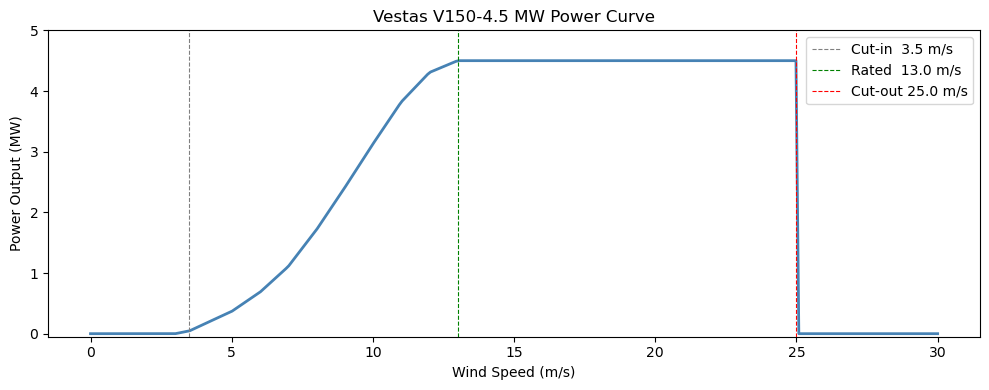

Rated power at 13 m/s: 4500.0 kW  (should be 4500)
Power at 3.4 m/s:      35.99999999999999 kW  (should be 0 — below cut-in)
Power at 26 m/s:       0.0 kW  (should be 0 — above cut-out)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Vestas V150-4.5 MW published power curve
# Source: Vestas datasheet V150-4.5 MW IEC S / IIIA
_v150_speeds = [0, 3.0, 3.5, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0,
                10.0, 11.0, 12.0, 13.0, 14.0, 25.0, 25.01, 50.0]
_v150_power  = [0,   0,   45, 154, 367, 683, 1106, 1711, 2405,
                3126, 3817, 4305, 4500, 4500, 4500,    0,    0]

_curve = interp1d(_v150_speeds, _v150_power, kind='linear',
                  bounds_error=False, fill_value=0.0)

def vestas_v150_power_kw(wind_ms):
    """Return power (kW) for given wind speed(s) in m/s."""
    return np.maximum(0.0, _curve(np.asarray(wind_ms, dtype=float)))

# Quick sanity plot
test_speeds = np.linspace(0, 30, 300)
test_power  = vestas_v150_power_kw(test_speeds)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test_speeds, test_power / 1000, color="steelblue", linewidth=2)
ax.axvline(x=3.5,  color="gray",  linestyle="--", linewidth=0.8, label="Cut-in  3.5 m/s")
ax.axvline(x=13.0, color="green", linestyle="--", linewidth=0.8, label="Rated  13.0 m/s")
ax.axvline(x=25.0, color="red",   linestyle="--", linewidth=0.8, label="Cut-out 25.0 m/s")
ax.set_xlabel("Wind Speed (m/s)")
ax.set_ylabel("Power Output (MW)")
ax.set_title("Vestas V150-4.5 MW Power Curve")
ax.legend()
ax.set_ylim(-0.05, 5.0)
plt.tight_layout()
plt.show()
print("Rated power at 13 m/s:", vestas_v150_power_kw(13.0), "kW  (should be 4500)")
print("Power at 3.4 m/s:     ", vestas_v150_power_kw(3.4),  "kW  (should be 0 — below cut-in)")
print("Power at 26 m/s:      ", vestas_v150_power_kw(26.0), "kW  (should be 0 — above cut-out)")

In [10]:
from pathlib import Path
import geopandas as gpd
import pandas as pd

GEOJSON_DIR = Path("../data_wind_farm_locations")
TURBINE_DENSITY_MW_PER_KM2 = 7.0

# Official MW capacities for legally enacted plans
ESTABLISHED_CAPACITY_MW = {
    "Pärnu linna tuuleenergeetika eriplaneeringu kehtestamine (Põlendmaa)": 86.0,
    "Lääneranna valla tuuleparkide eriplaneeringu kehtestamine ala 2 osas": 137.0,
}

# File → planning stage (same as earlier cells)
FILES = {
    "tuul_ep_kehtestatud.geojson":                   "established",
    "RMK_MARU_lepingus 3.geojson":                   "contractual",
    "Riigimaade_enampakkumine_voor_alad.geojson":     "auction_areas",
    "Riigimaade_enampakkumine_voor_kataster.geojson": "auction_cadastral",
    "tuulealad_DP.geojson":                          "detailed_plan",
    "tuuleenergeetika_KOV_EP_alad.geojson":          "municipal_plan",
}

# Name/municipality field per file (same as earlier cells)
NAME_FIELDS = {
    "tuul_ep_kehtestatud.geojson":                   ("Plan_nimi",     "KOV"),
    "RMK_MARU_lepingus 3.geojson":                   ("Ala_nimi",      "Arendaja"),
    "Riigimaade_enampakkumine_voor_alad.geojson":     ("Ala_nim",       "KOV"),
    "Riigimaade_enampakkumine_voor_kataster.geojson": ("Ala_nim",       "KOV"),
    "tuulealad_DP.geojson":                          ("DP_nimi",       None),
    "tuuleenergeetika_KOV_EP_alad.geojson":          ("Projekti_nimi", "Kohalik_omavalitsus"),
}

capacity_rows = []

for fname, stage in FILES.items():
    name_col, muni_col = NAME_FIELDS[fname]
    gdf_raw = gpd.read_file(GEOJSON_DIR / fname)
    # Project to UTM zone 35N (covers Estonia) for area calculation in metres
    gdf_utm = gdf_raw.to_crs("EPSG:32635")
    # Keep WGS84 version for centroid lat/lon
    gdf_wgs = gdf_raw.copy()
    if gdf_wgs.crs is None:
        gdf_wgs = gdf_wgs.set_crs(epsg=4326)
    elif gdf_wgs.crs.to_epsg() != 4326:
        gdf_wgs = gdf_wgs.to_crs(epsg=4326)

    for i, (_, row_utm) in enumerate(gdf_utm.iterrows()):
        row_wgs = gdf_wgs.iloc[i]
        area_km2    = row_utm.geometry.area / 1e6
        name        = row_utm.get(name_col) or f"{stage}_{i}"
        capacity_mw = ESTABLISHED_CAPACITY_MW.get(name, area_km2 * TURBINE_DENSITY_MW_PER_KM2)
        centroid_wgs = row_wgs.geometry.centroid
        capacity_rows.append({
            "area_name":      name,
            "planning_stage": stage,
            "lat":            round(centroid_wgs.y, 6),
            "lon":            round(centroid_wgs.x, 6),
            "area_km2":       round(area_km2, 4),
            "capacity_mw":    round(capacity_mw, 2),
        })

capacity_df = pd.DataFrame(capacity_rows)

# Check established plans match expected values
est_check = capacity_df[capacity_df.planning_stage == "established"][["area_name", "area_km2", "capacity_mw"]]
print("Established plan capacities:")
print(est_check.to_string(index=False))

# Sum capacity by (lat, lon) — some polygons share a centroid after rounding
capacity_by_loc = (capacity_df
                   .groupby(["lat", "lon"], as_index=False)["capacity_mw"]
                   .sum())
total_mw = capacity_by_loc["capacity_mw"].sum()
print(f"\nTotal planned capacity across all {len(capacity_by_loc)} unique locations: {total_mw:.0f} MW")
print(f"(from {len(capacity_df)} polygons across 6 planning stages)")

Established plan capacities:
                                                           area_name  area_km2  capacity_mw
Pärnu linna tuuleenergeetika eriplaneeringu kehtestamine (Põlendmaa)   19.3771         86.0
Lääneranna valla tuuleparkide eriplaneeringu kehtestamine ala 2 osas    7.1931        137.0

Total planned capacity across all 143 unique locations: 40313 MW
(from 150 polygons across 6 planning stages)


In [11]:
HUB_HEIGHT_M    = 105.0   # Vestas V150 typical onshore hub height
REF_HEIGHT_M    = 10.0    # OpenWeatherMap measurement height
WIND_SHEAR_ALPHA = 0.143  # 1/7 power law (standard open-country terrain)
R_DRY           = 287.05  # J/(kg·K)
RHO_STD         = 1.225   # kg/m³  (ISO standard air density at 15 °C, 1013.25 hPa)
RATED_KW        = 4500.0  # Vestas V150-4.5 MW

wdf = weather_df.copy()

# 1. Wind shear: extrapolate from 10 m to hub height
shear_factor = (HUB_HEIGHT_M / REF_HEIGHT_M) ** WIND_SHEAR_ALPHA
wdf["wind_hub_ms"] = wdf["wind_speed_ms"] * shear_factor
print(f"Wind shear factor (10 m → {HUB_HEIGHT_M:.0f} m): {shear_factor:.4f}×")

# 2. Air density from measured temperature + pressure
wdf["rho"] = (wdf["pressure_hpa"] * 100.0) / (R_DRY * (wdf["temp_c"] + 273.15))
wdf["density_correction"] = (wdf["rho"] / RHO_STD) ** (1.0 / 3.0)
print(f"Mean air density: {wdf['rho'].mean():.4f} kg/m³  (std {wdf['rho'].std():.4f})")
print(f"Mean density correction factor: {wdf['density_correction'].mean():.4f}")

# 3. Power fraction from curve (normalised 0–1), then density-corrected
wdf["power_fraction"] = vestas_v150_power_kw(wdf["wind_hub_ms"].values) / RATED_KW
wdf["power_fraction_corrected"] = (wdf["power_fraction"] * wdf["density_correction"]).clip(0.0, 1.0)
print(f"\nMean capacity factor across all locations/hours: {wdf['power_fraction_corrected'].mean():.3f}")

# 4. Join per-location capacity (MW)
wdf = wdf.merge(capacity_by_loc, on=["lat", "lon"], how="left")
missing_cap = wdf["capacity_mw"].isna().sum()
if missing_cap:
    print(f"WARNING: {missing_cap} rows have no capacity match — setting to 0")
wdf["capacity_mw"] = wdf["capacity_mw"].fillna(0.0)

# 5. MW output per location-hour
wdf["power_mw"] = wdf["power_fraction_corrected"] * wdf["capacity_mw"]

# 6. Aggregate to total Estonian wind per hour
hourly_wind = (
    wdf.groupby("timestamp")["power_mw"]
       .sum()
       .reset_index()
       .rename(columns={"power_mw": "total_wind_mw"})
)
hourly_wind["timestamp"] = pd.to_datetime(hourly_wind["timestamp"])
hourly_wind = hourly_wind.sort_values("timestamp").reset_index(drop=True)

print(f"\nHourly production summary (MW):")
print(hourly_wind["total_wind_mw"].describe().round(1))

# 7. Save
out_path = Path("../data_wind_farm_locations/simulated_wind_production_jan2026.csv")
hourly_wind.to_csv(out_path, index=False)
print(f"\nSaved {len(hourly_wind)} hourly records → {out_path}")

Wind shear factor (10 m → 105 m): 1.3997×
Mean air density: 1.3404 kg/m³  (std 0.0274)
Mean density correction factor: 1.0304

Mean capacity factor across all locations/hours: 0.113

Hourly production summary (MW):
count      744.0
mean      3488.6
std       5873.3
min          0.0
25%         65.6
50%       1002.4
75%       4027.0
max      28607.2
Name: total_wind_mw, dtype: float64

Saved 744 hourly records → ../data_wind_farm_locations/simulated_wind_production_jan2026.csv


## Step 7: Visualise Simulated Production

Three validation plots:
1. **Total hourly wind production** over January 2026 — cross-check with known crisis periods
2. **Capacity factor distribution** — should cluster around 20–50 % for onshore January Estonia
3. **Power curve validation** — scatter of hub-height wind speed vs. actual power fraction

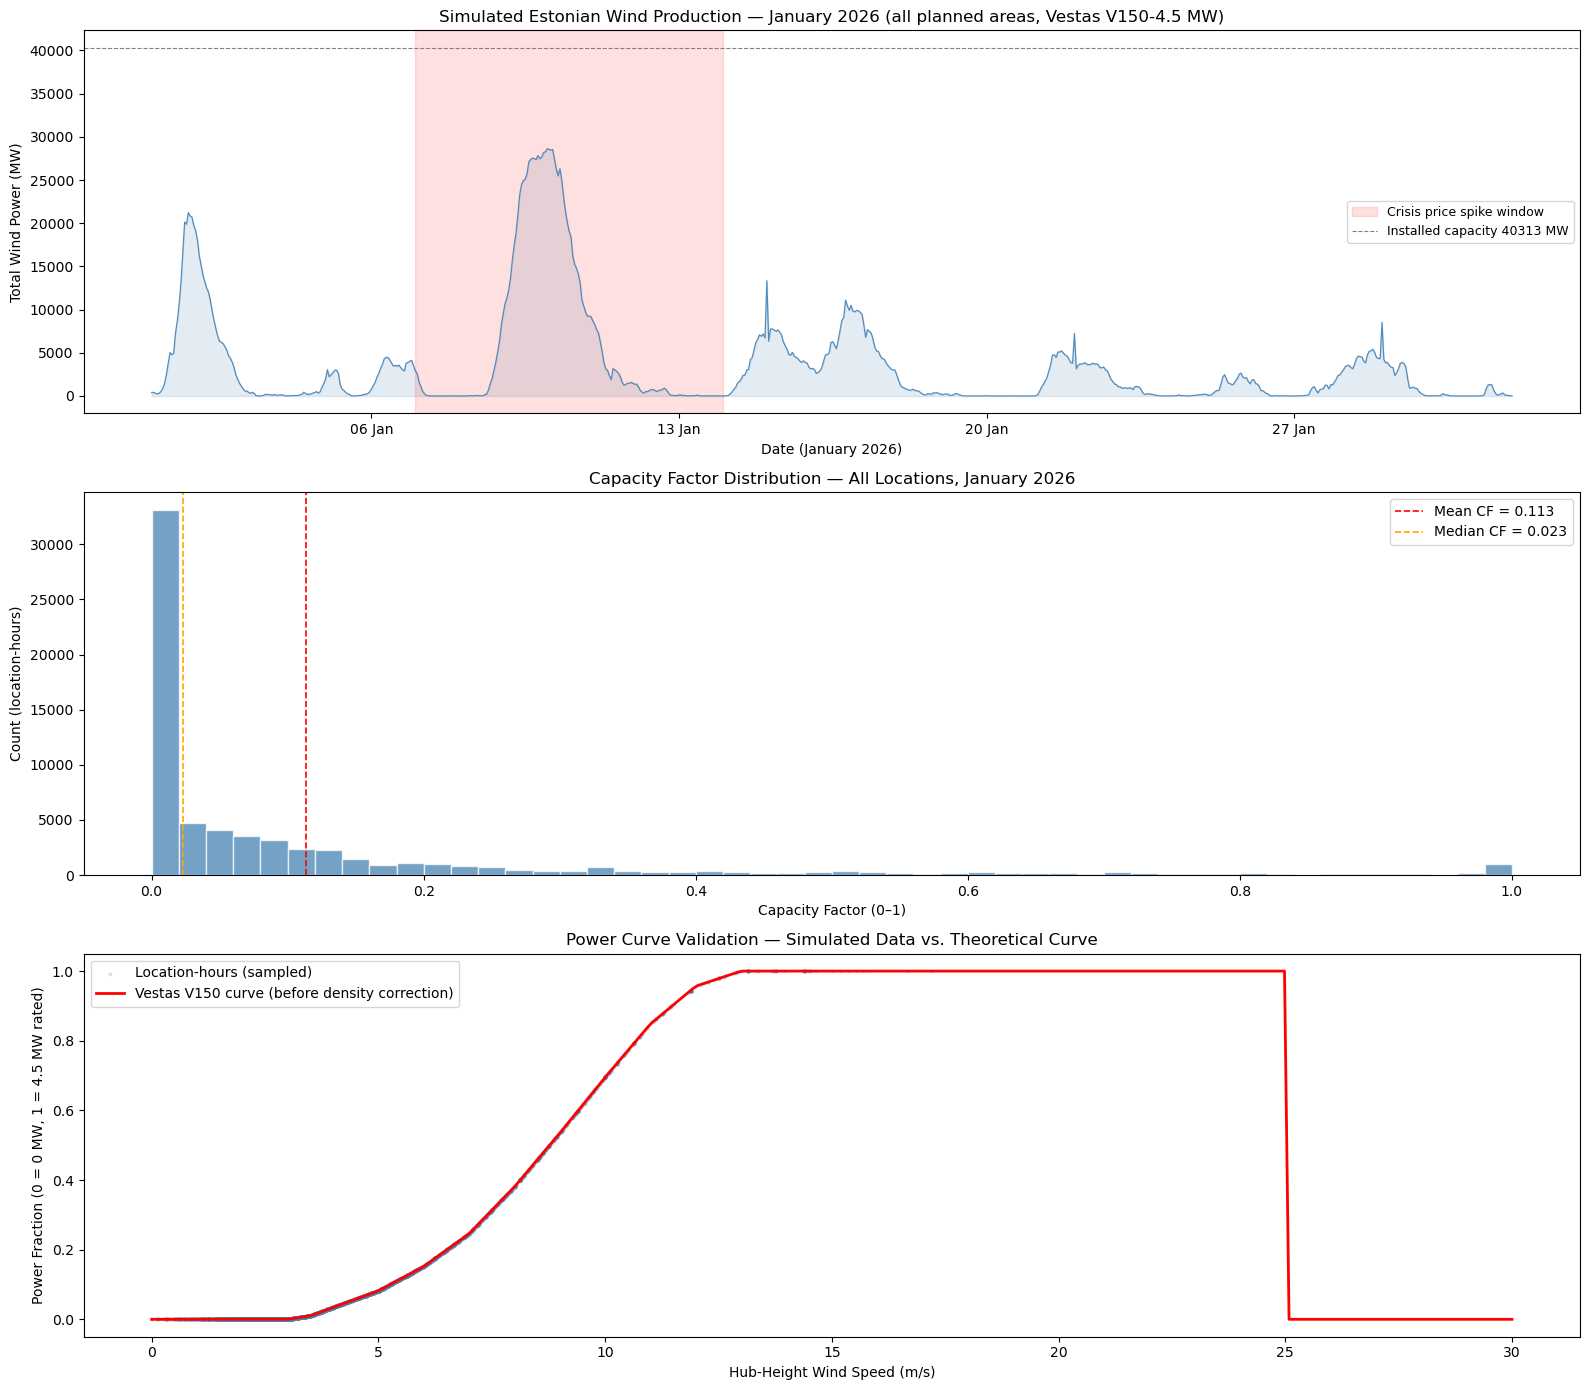


Total installed capacity modelled: 40313 MW
Peak hourly production:            28607 MW  (71.0% of capacity)
Mean hourly production:            3489 MW  (8.7% of capacity)
Hours at zero output (all calm):   47 / 744


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# --- Plot 1: Total simulated wind production ---
ax = axes[0]
ax.plot(hourly_wind["timestamp"], hourly_wind["total_wind_mw"],
        color="steelblue", linewidth=0.9, alpha=0.9)
ax.fill_between(hourly_wind["timestamp"], hourly_wind["total_wind_mw"],
                alpha=0.15, color="steelblue")

# Annotate the crisis price spike period (around Jan 7–14 2026 when prices hit €655/MWh)
ax.axvspan(pd.Timestamp("2026-01-07"), pd.Timestamp("2026-01-14"),
           alpha=0.12, color="red", label="Crisis price spike window")

total_cap_mw = capacity_by_loc["capacity_mw"].sum()
ax.axhline(y=total_cap_mw, color="gray", linestyle="--", linewidth=0.8,
           label=f"Installed capacity {total_cap_mw:.0f} MW")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.set_xlabel("Date (January 2026)")
ax.set_ylabel("Total Wind Power (MW)")
ax.set_title("Simulated Estonian Wind Production — January 2026 (all planned areas, Vestas V150-4.5 MW)")
ax.legend(fontsize=9)

# --- Plot 2: Capacity factor distribution ---
ax = axes[1]
cf = wdf[wdf["capacity_mw"] > 0]["power_fraction_corrected"]
ax.hist(cf, bins=50, color="steelblue", alpha=0.75, edgecolor="white")
ax.axvline(x=cf.mean(), color="red", linestyle="--", linewidth=1.2,
           label=f"Mean CF = {cf.mean():.3f}")
ax.axvline(x=cf.median(), color="orange", linestyle="--", linewidth=1.2,
           label=f"Median CF = {cf.median():.3f}")
ax.set_xlabel("Capacity Factor (0–1)")
ax.set_ylabel("Count (location-hours)")
ax.set_title("Capacity Factor Distribution — All Locations, January 2026")
ax.legend()

# --- Plot 3: Wind speed vs power fraction (curve validation) ---
ax = axes[2]
sample = wdf[wdf["capacity_mw"] > 0].sample(min(5000, len(wdf)), random_state=42)
ax.scatter(sample["wind_hub_ms"], sample["power_fraction"],
           alpha=0.15, s=4, color="steelblue", label="Location-hours (sampled)")
# Overlay theoretical curve
v_range = np.linspace(0, 30, 300)
ax.plot(v_range, vestas_v150_power_kw(v_range) / RATED_KW,
        color="red", linewidth=2, label="Vestas V150 curve (before density correction)")
ax.set_xlabel("Hub-Height Wind Speed (m/s)")
ax.set_ylabel("Power Fraction (0 = 0 MW, 1 = 4.5 MW rated)")
ax.set_title("Power Curve Validation — Simulated Data vs. Theoretical Curve")
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nTotal installed capacity modelled: {total_cap_mw:.0f} MW")
print(f"Peak hourly production:            {hourly_wind['total_wind_mw'].max():.0f} MW  ({hourly_wind['total_wind_mw'].max()/total_cap_mw*100:.1f}% of capacity)")
print(f"Mean hourly production:            {hourly_wind['total_wind_mw'].mean():.0f} MW  ({hourly_wind['total_wind_mw'].mean()/total_cap_mw*100:.1f}% of capacity)")
print(f"Hours at zero output (all calm):   {(hourly_wind['total_wind_mw'] < 1).sum()} / {len(hourly_wind)}")